# STAT 207 Group Lab Assignment 13 - [10 total points]

## Measuring Model Performance & Model Searching

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  Also, discuss and record if you've ever been on a cruise before.

mdm16


## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to assess model fit and overfitting through model searching.
<hr>

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [8]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

## Case Study: Crew Size on Cruise Ships

We will look at data collected about the size of a crew (in hundreds) on cruise ships.  In particular, we would like to be able to predict the size of the crew needed for a cruise ship from other characteristics about that ship.  The original data can be found here: https://github.com/bot13956/ML_Model_for_Predicting_Ships_Crew_Size/blob/master/cruise_ship_info.csv.

For this case study, we will consider the following variables:

- **Age**: the age of the ship (years)
- **Tonnage**: the amount of water the ship displaces
- **passengers**: the max number of passengers the ship can hold (in 100s)
- **length**: the length of the ship (in hundrds of feet)
- **cabins**: the number of cabins (in 100s)
- **passenger_density**: a space ratio for how much space is on board per passenger
- **crew**: the number of crew members on the ship (in 100s)

The code cell below will read in the data for you and create a test and training set.  Be sure to run the cell. 

In [9]:
df = pd.read_csv('cruise_ship_info.csv')
df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 425)

### 1. [4 points] Searching for a Good Model

**a)** Perform forward selection using the adjusted $R^2$ ($R^2_\text{adj}$) as your metric on your training data.

In [11]:
candidate_vars = ['Age', 'Tonnage', 'passengers', 'length', 'cabins', 'passenger_density']
selected_vars = []
remaining_vars = candidate_vars.copy()
best_adj_r2 = float('-inf')
forward_steps = []

while len(remaining_vars) > 0:
    step_results = []
    
    for var in remaining_vars:
        current_vars = selected_vars + [var]
        formula = 'crew ~ ' + ' + '.join(current_vars)
        model = smf.ols(formula=formula, data=df_train).fit()
        step_results.append((var, model.rsquared_adj))
    
    best_var, best_step_adj_r2 = max(step_results, key=lambda x: x[1])
    
    if best_step_adj_r2 > best_adj_r2:
        selected_vars.append(best_var)
        remaining_vars.remove(best_var)
        best_adj_r2 = best_step_adj_r2
        forward_steps.append([best_var, best_adj_r2, selected_vars.copy()])
    else:
        break

forward_results = pd.DataFrame(forward_steps, columns=['added_variable', 'adjusted_R2', 'model_variables'])
forward_results

,added_variable,adjusted_R2,model_variables
0,cabins,0.920113,[cabins]
1,length,0.927124,"[cabins, length]"
2,passengers,0.931010,"[cabins, length, passengers]"
3,Tonnage,0.932128,"[cabins, length, passengers, Tonnage]"


In [16]:
final_model = smf.ols(formula='crew ~ cabins + length + passengers + Tonnage', data=df_train).fit()
final_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   crew   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     430.2
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.67e-70
Time:                        00:54:04   Log-Likelihood:                -166.95
No. Observations:                 126   AIC:                             343.9
Df Residuals:                     121   BIC:                             358.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5085      0.630     -0.807      0.421      -1.756       0.740
cabins         0.7955      0.089      8.974      0.000       0.620       0.971
length         0.3137      0.120      2.607      0.010       0.075       0.552
passengers    -0.1306      0.040     -3.237      0.002      -0.211      -0.051
Tonnage        0.0152      0.009      1.735      0.085      -0.002       0.032
==============================================================================
Omnibus:                      132.153   Durbin-Watson:                   2.125
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3664.597
Skew:                           3.452   Prob(JB):                         0.00
Kurtosis:                      28.502   Cond. No.                         664.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**b)** Briefly summarize the results of this selection process.  Be sure to answer:
- What was your starting model?
- What was the most important initial variable to add to the model?
- What was your final model?
- What was the $R^2_\text{adj}$ of your final model?

We started with a null model meaning with no preidctor variables and only an intercept. IN teh first step of the forward selection cabins was the most important vairable to add because it gave us the larges increase in Adj Rsquared. The final model was cabins, length, passengers, and Tonnage to predict crew. The final Adj Rsquared was .93218


### 2. [2.5 points]  Check for Multicollinearity

**a)** Now, check your model that you selected in Question 1 after forward selection for multicollinearity.  You may use either a visualization or summary statistics to check.

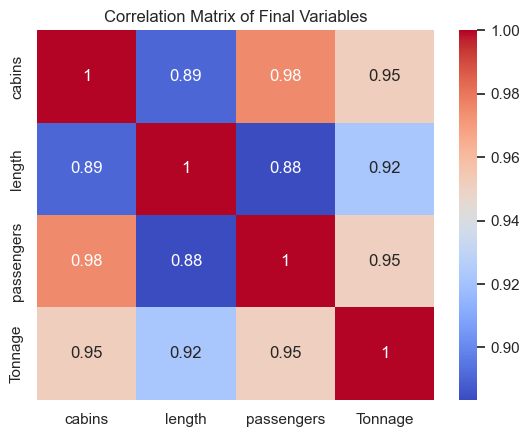

In [13]:
final_vars = ['cabins', 'length', 'passengers', 'Tonnage']

corr_matrix = df_train[final_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Final Variables')
plt.show()


**b)** Based on what you see from part a, which variables (if any) would you like to remove from your model to reduce multicollinearity?  Briefly explain how you selected your variables that you wanted to remove.  Then, fit a new model to the training data using your reduced set of selected predictors.

*Note*: If you are satisfied with your current model for multicollinearity, pick the least important predictor to remove from the model, and fit an updated model to the training data with your selected predictors.  Be sure to explain why you did not want to remove any variables.

*Second note*: there is not a single correct answer here.  We are hoping that you make a reasonable choice based on your current understanding of the data.

We see that all heatmap shows that all the predictors in the model are highly correlated with one another. This heavily suggest that multipcollinearity is present. I decied to remove Tonnage becasue it was the last vairable added in the seleciton process. It is also highly correlated with the other variables and so I chose to remove this. 

In [14]:
reduced_model = smf.ols(formula='crew ~ cabins + length + passengers', data=df_train).fit()
reduced_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   crew   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     563.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.85e-71
Time:                        00:48:15   Log-Likelihood:                -168.50
No. Observations:                 126   AIC:                             345.0
Df Residuals:                     122   BIC:                             356.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0441      0.554     -1.884      0.062      -2.141       0.053
cabins         0.8333      0.087      9.619      0.000       0.662       1.005
length         0.4223      0.104      4.075      0.000       0.217       0.628
passengers    -0.1089      0.039     -2.815      0.006      -0.185      -0.032
==============================================================================
Omnibus:                      127.970   Durbin-Watson:                   2.171
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3189.157
Skew:                           3.326   Prob(JB):                         0.00
Kurtosis:                      26.732   Cond. No.                         167.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 3. [3.5 points] Comparing Our Two Models for Overfitting

We now have two candidate models: our model from forward selection in Question 1 and our reduced model from Question 2.  In this question, we'll aim to identify which model performs better on *new* data.

**a)** Calculate the RMSE for each of our two models on each of our two data sets: the training and the test set.  Be sure that you use the same original model for both calculations (that is, you don't need to re-fit a second version of your model to your test data).

In [17]:

forward_train_pred = final_model.predict(df_train)
forward_test_pred = final_model.predict(df_test)

reduced_train_pred = reduced_model.predict(df_train)
reduced_test_pred = reduced_model.predict(df_test)

forward_train_rmse = (((df_train['crew'] - forward_train_pred) ** 2).mean()) ** 0.5
forward_test_rmse = (((df_test['crew'] - forward_test_pred) ** 2).mean()) ** 0.5
reduced_train_rmse = (((df_train['crew'] - reduced_train_pred) ** 2).mean()) ** 0.5
reduced_test_rmse = (((df_test['crew'] - reduced_test_pred) ** 2).mean()) ** 0.5

rmse_results = pd.DataFrame({
    'model': ['forward model', 'forward model', 'reduced model', 'reduced model'],
    'dataset': ['training', 'test', 'training', 'test'],
    'RMSE': [forward_train_rmse, forward_test_rmse, reduced_train_rmse, reduced_test_rmse]
})

rmse_results


,model,dataset,RMSE
0,forward model,training,0.910363
1,forward model,test,1.167520
2,reduced model,training,0.921619
3,reduced model,test,1.187445


**b)** Based on these results, which model would you prefer?  Briefly explain how you picked your preferred model.

I would prefer the forward selection model because it had a lower RMSE for both training and test data. Since lower RMSE indicates better predictive performance, the selection model appears to perform slightly better.

**c)** Do your results from Question 1 (forward searching) and Question 3 (RMSE) suggest using the same model?  

We used three different metrics for our three different questions: $R^2_\text{adj}$ (Question 1), multicollinearity (Question 2), and RMSE (Question 3).  These metrics prioritize different characteristics of a model.  What characteristic of a model do these metrics prioritize?

*Note:* You should answer this question separately for each metric.

Yes the results from Q1 and Q3 suggest usint the same model. In Q1 forward selection using adj R2 selected model with cabins,length,passanger,Tonnage. In Q3 that same forward selection model had a lower RMSE on both trianing and test data. So both results work to support choosing this modle.

The three metrics eqach prioritize different features of model qualityADj R2 priotizes overal model fit while penalizing unnecessary variables.

Multicollinearity prioitize how indepent the predictor variables are from one another so it helps identify whether predictors are too strongly related and may make coeeficient. 

RMSE prioritize predictive accuracy since it measures how close the model's predictions are to the actual response values with lower RMSE indicating better prediction

### 4. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  AI should not be used on Questions 1b, 2b, 3b, and 3c of this assignment.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

no

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

n/a
